In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import os.path as op

In [52]:
bids_folder = '/Users/mrenke/data/ds-stressrisk/'
subject = '01'
session = 1
mask = 'NPC_R'
space = 'T1w'
n_voxels = 250
smoothed = True

pca_confounds=False
N_runs = 6 #the way python counts
task_name='risk'

decod_dir = op.join(bids_folder, 'derivatives', 'decoded_pdfs.volume', )
if smoothed:
    decod_dir += '.smoothed'
decod_dir = op.join(decod_dir,f'sub-{subject}')
df = pd.read_csv(op.join(decod_dir, f'sub-{subject}_ses-{session}_mask-{mask}_nvoxels-{n_voxels}_space-{space}_pars.tsv'),
sep='\t', header=0, index_col=1)


df = df.drop(df.columns[0], axis=1)
df.columns.name = 'n'
pdf = df

<AxesSubplot:xlabel='n'>

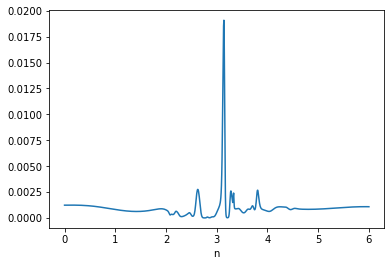

In [53]:
pdf.columns = pdf.columns.astype(float)
pdf.loc[3].plot() # plot example posterior estimate of one trial (here trial-n. 1)

In [54]:
E = (pdf * pdf.columns).sum(1) / pdf.sum(1) # expected value --> presented stimulus
E.name='E'

In [44]:

paradigm = [pd.read_csv(op.join(bids_folder, f'sub-{subject}', f'ses-{session}',
                                'func', f'sub-{subject}_ses-{session}_task-risk_run-{run}_events.tsv'), sep='\t')
            for run in range(1, N_runs+1)]

paradigm = pd.concat(paradigm)

paradigm = paradigm[paradigm.trial_type ==
                    'stimulus 1'].set_index('trial_nr', append=True)

paradigm['log(n1)'] = np.log(paradigm['n1'])

In [45]:
paradigm.droplevel(0).join(E)

,onset,trial_type,prob1,prob2,n1,n2,choice,log(n1),E
trial_nr,,,,,,,,,
1,13.262439,stimulus 1,0.55,1.00,18.0,10.0,NaN,2.890372,3.132899
2,27.908664,stimulus 1,0.55,1.00,23.0,10.0,NaN,3.135494,3.069144
3,43.573135,stimulus 1,0.55,1.00,41.0,20.0,NaN,3.713572,3.179966
4,55.717712,stimulus 1,0.55,1.00,53.0,20.0,NaN,3.970292,3.004532
5,67.862280,stimulus 1,0.55,1.00,21.0,7.0,NaN,3.044522,3.073852
...,...,...,...,...,...,...,...,...,...
116,235.517735,stimulus 1,1.00,0.55,20.0,32.0,NaN,2.995732,2.840087
117,251.665947,stimulus 1,1.00,0.55,20.0,47.0,NaN,2.995732,3.123870
118,265.812411,stimulus 1,1.00,0.55,14.0,22.0,NaN,2.639057,2.768533


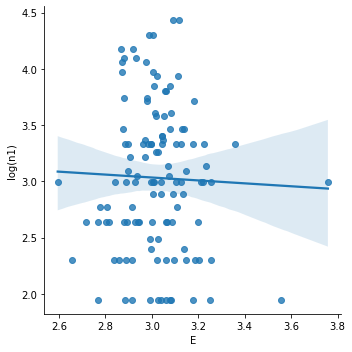

In [47]:
paradigm = paradigm.join(E)
sns.lmplot(x='E', y='log(n1)', data=paradigm)

In [48]:
import pingouin
pingouin.corr(paradigm['E'], paradigm['log(n1)'])

,n,r,CI95%,p-val,BF10,power
pearson,120,-0.030906,"[-0.21, 0.15]",0.737557,0.121,0.062862
